# Exploratory Data Analysis and Trend Assessment of FDA-Approved Peptide Drugs
## Abstract:
Peptide based drugs are emerging as a high growth therapeutics, driven by
increasing approvals in current market which provides high specificity and favorable safety profile.This project performs an exploratory data analysis (EDA) and  trend analysis of FDA-approval of  peptide drugs using publicly available FDA regulatory datasets(accessed on 02Feb,2026) to support strategic investment, market competitors, Research and Development decisions. This study uncovers approval trends, formulation patterns, sponsor dynamics, and lifecycle behaviors of peptide drugs.

##Business / Research Problem:
How has FDA approval of peptide drugs changed over time?

What dosage forms and routes of administration dominate peptide therapeutics?

Which sponsors have historically led peptide drug approvals?

How active are peptide drugs post-approval (supplements, label changes)?

What patterns distinguish long-lived peptide drugs from discontinued ones?

![Alt Text](https://www.reuters.com/resizer/v2/F2VJ5IGNSJPL5PW5IYE7KJBT2A.jpg?auth=b998cc512fff0b775a49f6a6c6f8a11d8dd6d10b88c7ec422ae22e025909eda4&width=1920&quality=80
)

# FDA Dataset loading
1. Applications (FDA approval application)
2. Applications Docs
3. Products
4. Marketing Status

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Application Dataset
applications=pd.read_csv("/content/Applications.txt", sep='\t', dtype=str)

In [3]:
applications.head()

,ApplNo,ApplType,ApplPublicNotes,SponsorName
0,000004,NDA,NaN,PHARMICS
1,000159,NDA,NaN,LILLY
2,000552,NDA,NaN,ASPEN GLOBAL INC
3,000734,NDA,NaN,LILLY
4,000793,NDA,NaN,PHARMOBEDIENT


In [4]:
#Application Docs dataset
applications_docs=pd.read_csv("/content/ApplicationDocs.txt", sep='\t', dtype=str, encoding='cp1252', on_bad_lines='skip')

In [5]:
applications_docs.head()

,ApplicationDocsID,ApplicationDocsTypeID,ApplNo,SubmissionType,SubmissionNo,ApplicationDocsTitle,ApplicationDocsURL,ApplicationDocsDate
0,1,1,004782,SUPPL,125,0,http://www.accessdata.fda.gov/drugsatfda_docs/...,2003-07-28 00:00:00
1,2,1,004782,SUPPL,128,0,http://www.accessdata.fda.gov/drugsatfda_docs/...,2002-11-27 00:00:00
2,3,1,004782,SUPPL,130,0,http://www.accessdata.fda.gov/drugsatfda_docs/...,2003-05-16 00:00:00
3,4,1,004782,SUPPL,138,0,http://www.accessdata.fda.gov/drugsatfda_docs/...,2005-04-12 00:00:00
4,5,1,004782,SUPPL,141,0,http://www.accessdata.fda.gov/drugsatfda_docs/...,2005-08-04 00:00:00


In [6]:
#Products dataset
products= pd.read_csv("/content/Products.txt", sep="\t", dtype=str)

In [7]:
products.head()

,ApplNo,ProductNo,Form,Strength,ReferenceDrug,DrugName,ActiveIngredient,ReferenceStandard
0,000004,004,SOLUTION/DROPS;OPHTHALMIC,1%,0,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,0
1,000159,001,TABLET;ORAL,500MG,0,SULFAPYRIDINE,SULFAPYRIDINE,0
2,000552,001,INJECTABLE;INJECTION,"20,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0
3,000552,002,INJECTABLE;INJECTION,"40,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0
4,000552,003,INJECTABLE;INJECTION,"5,000 UNITS/ML",0,LIQUAEMIN SODIUM,HEPARIN SODIUM,0


In [8]:
#Marketing Dataset
marketing_stat= pd.read_csv("/content/MarketingStatus.txt",sep="\t", dtype=str)

In [9]:
marketing_stat.head()

,MarketingStatusID,ApplNo,ProductNo
0,3,000004,004
1,3,000159,001
2,3,000552,001
3,3,000552,002
4,3,000552,003


In [10]:
applications_date=applications_docs[['ApplNo','ApplicationDocsDate']]


In [11]:
applications_date["ApplicationDocsDate"]=pd.to_datetime(applications_date["ApplicationDocsDate"])
applications_date["ApplicationDocsDate"]=applications_date["ApplicationDocsDate"].dt.year

/tmp/ipykernel_653/3403659968.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  applications_date["ApplicationDocsDate"]=pd.to_datetime(applications_date["ApplicationDocsDate"])
/tmp/ipykernel_653/3403659968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  applications_date["ApplicationDocsDate"]=applications_date["ApplicationDocsDate"].dt.year


# Data Integration and Data Cleaning

In [12]:


application_clean1=pd.merge(applications, applications_date, on="ApplNo",how="inner" )
application_clean1["ApplNo"]= application_clean1["ApplNo"].astype(int)
app_cln=application_clean1.drop_duplicates(subset=["ApplNo"], keep="first")

In [13]:
app_cln

,ApplNo,ApplType,ApplPublicNotes,SponsorName,ApplicationDocsDate
0,552,NDA,NaN,ASPEN GLOBAL INC,2024
2,793,NDA,NaN,PHARMOBEDIENT,2007
7,1504,NDA,NaN,THE VERARD COMPANY,2019
8,1546,NDA,NaN,MERCK SHARP DOHME,2002
9,2918,NDA,NaN,POYTHRESS,2018
...,...,...,...,...,...
78903,761458,BLA,NaN,GLAXOSMITHKLINE LLC,2025
78905,761464,BLA,NaN,DAIICHI SANKYO INC,2025
78909,761467,BLA,NaN,MERCK SHARP DOHME,2025
78920,761473,BLA,NaN,FORMYCON AG,2025


In [14]:
products=products[['ApplNo','Form','DrugName','ActiveIngredient','ProductNo']].drop_duplicates()

In [15]:
products.head()


,ApplNo,Form,DrugName,ActiveIngredient,ProductNo
0,000004,SOLUTION/DROPS;OPHTHALMIC,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,004
1,000159,TABLET;ORAL,SULFAPYRIDINE,SULFAPYRIDINE,001
2,000552,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001
3,000552,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,002
4,000552,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,003


In [16]:
products['ApplNo']=products['ApplNo'].astype(int)
appl_cln1=pd.merge(app_cln,products, on="ApplNo", how="inner")

In [17]:
appl_cln1

,ApplNo,ApplType,ApplPublicNotes,SponsorName,ApplicationDocsDate,Form,DrugName,ActiveIngredient,ProductNo
0,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001
1,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,002
2,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,003
3,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,004
4,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,005
...,...,...,...,...,...,...,...,...,...
19292,761464,BLA,NaN,DAIICHI SANKYO INC,2025,INJECTABLE;INJECTION,DATROWAY,DATOPOTAMAB DERUXTECAN-DLNK,001
19293,761467,BLA,NaN,MERCK SHARP DOHME,2025,INJECTABLE;INJECTION,KEYTRUDA QLEX,PEMBROLIZUMAB;BERAHYALURONIDASE ALFA-PMPH,001
19294,761467,BLA,NaN,MERCK SHARP DOHME,2025,INJECTABLE;INJECTION,KEYTRUDA QLEX,PEMBROLIZUMAB;BERAHYALURONIDASE ALFA-PMPH,002
19295,761473,BLA,NaN,FORMYCON AG,2025,INJECTION,NUFYMCO,RANIBIZUMAB-LEYK,001


In [18]:
marketing_stat.head()

,MarketingStatusID,ApplNo,ProductNo
0,3,000004,004
1,3,000159,001
2,3,000552,001
3,3,000552,002
4,3,000552,003


In [19]:
# to chekc the unique values of marketing status
marketing_stat["MarketingStatusID"].unique()

array(['3', '1', '2', '4', '5'], dtype=object)

In [20]:
# to convert the marketing status from numeric coding to categorical values
def FDA_merk_stat(val):
  if val=='1':
    return 'Prescription'
  elif val=='2':
    return 'OTC'
  elif val== '3':
    return 'Discontinued'
  elif val=='4':
    return 'Tentative Approval'
  else:
      return 'Incomplete Data'

In [21]:
marketing_stat['Status']=marketing_stat['MarketingStatusID'].apply(FDA_merk_stat)

In [22]:
marketing_stat=marketing_stat.drop(columns='ProductNo')

In [23]:
marketing_stat['ApplNo']=marketing_stat['ApplNo'].astype(int)
appl_cln2=pd.merge(appl_cln1,marketing_stat, on="ApplNo", how="left")

In [24]:
#Merged Dataset
appl_cln2.head(100)

,ApplNo,ApplType,ApplPublicNotes,SponsorName,ApplicationDocsDate,Form,DrugName,ActiveIngredient,ProductNo,MarketingStatusID,Status
0,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001,3,Discontinued
1,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001,3,Discontinued
2,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001,3,Discontinued
3,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001,3,Discontinued
4,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001,3,Discontinued
...,...,...,...,...,...,...,...,...,...,...,...
95,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,HEPARIN SODIUM,HEPARIN SODIUM,009,3,Discontinued
96,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,HEPARIN SODIUM,HEPARIN SODIUM,010,3,Discontinued
97,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,HEPARIN SODIUM,HEPARIN SODIUM,010,3,Discontinued
98,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,HEPARIN SODIUM,HEPARIN SODIUM,010,3,Discontinued


In [25]:
#Cleaned Dataset
appl_cln3=appl_cln2.drop_duplicates()

In [26]:
appl_cln3

,ApplNo,ApplType,ApplPublicNotes,SponsorName,ApplicationDocsDate,Form,DrugName,ActiveIngredient,ProductNo,MarketingStatusID,Status
0,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,001,3,Discontinued
12,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,002,3,Discontinued
24,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,003,3,Discontinued
36,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,004,3,Discontinued
48,552,NDA,NaN,ASPEN GLOBAL INC,2024,INJECTABLE;INJECTION,LIQUAEMIN SODIUM,HEPARIN SODIUM,005,3,Discontinued
...,...,...,...,...,...,...,...,...,...,...,...
63933,761464,BLA,NaN,DAIICHI SANKYO INC,2025,INJECTABLE;INJECTION,DATROWAY,DATOPOTAMAB DERUXTECAN-DLNK,001,1,Prescription
63934,761467,BLA,NaN,MERCK SHARP DOHME,2025,INJECTABLE;INJECTION,KEYTRUDA QLEX,PEMBROLIZUMAB;BERAHYALURONIDASE ALFA-PMPH,001,1,Prescription
63936,761467,BLA,NaN,MERCK SHARP DOHME,2025,INJECTABLE;INJECTION,KEYTRUDA QLEX,PEMBROLIZUMAB;BERAHYALURONIDASE ALFA-PMPH,002,1,Prescription
63938,761473,BLA,NaN,FORMYCON AG,2025,INJECTION,NUFYMCO,RANIBIZUMAB-LEYK,001,1,Prescription


In [27]:
# The most of the peptide drugs are in the category of Biologics (BLA)
appl_cln3=appl_cln3[appl_cln2['ApplType']=="BLA"]

/tmp/ipykernel_653/2942924949.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  appl_cln3=appl_cln3[appl_cln2['ApplType']=="BLA"]


In [28]:
# filtering the active ingredient for peptide drugs using specific prefixes
peptide_suffix=("TIDE","MAB","GLUTIDE","PRESSIN","RELIN","NCIN")


In [29]:
appl_cln3['ActiveIngredient']=appl_cln3['ActiveIngredient'].fillna("").str.upper().str.strip()

/tmp/ipykernel_653/445047860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  appl_cln3['ActiveIngredient']=appl_cln3['ActiveIngredient'].fillna("").str.upper().str.strip()


In [30]:
appl_cln3['Is_peptide']=appl_cln3['ActiveIngredient'].str.contains("|".join(peptide_suffix),regex=True)

/tmp/ipykernel_653/219831757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  appl_cln3['Is_peptide']=appl_cln3['ActiveIngredient'].str.contains("|".join(peptide_suffix),regex=True)


In [31]:
peptide_drugs=appl_cln3[appl_cln3['Is_peptide']== True]

In [32]:
peptide_drugs

,ApplNo,ApplType,ApplPublicNotes,SponsorName,ApplicationDocsDate,Form,DrugName,ActiveIngredient,ProductNo,MarketingStatusID,Status,Is_peptide
12308,20162,BLA,NaN,FERRING,2020,INJECTABLE;INJECTION,ACTHREL,CORTICORELIN OVINE TRIFLUTATE,001,1,Prescription,True
23899,22505,BLA,NaN,THERATECHNOLOGIES,2020,POWDER;SUBCUTANEOUS,EGRIFTA,TESAMORELIN ACETATE,001,1,Prescription,True
23901,22505,BLA,NaN,THERATECHNOLOGIES,2020,POWDER;SUBCUTANEOUS,EGRIFTA,TESAMORELIN ACETATE,002,1,Prescription,True
41896,103575,BLA,NaN,CENTOCOR INC,2004,INJECTABLE; INJECTION,REOPRO,ABCIXIMAB,001,1,Prescription,True
41897,103608,BLA,NaN,CYTOGEN,2004,VIAL; INTRAVENOUS,PROSTASCINT,CAPROMAB PENDETIDE,001,1,Prescription,True
...,...,...,...,...,...,...,...,...,...,...,...,...
63933,761464,BLA,NaN,DAIICHI SANKYO INC,2025,INJECTABLE;INJECTION,DATROWAY,DATOPOTAMAB DERUXTECAN-DLNK,001,1,Prescription,True
63934,761467,BLA,NaN,MERCK SHARP DOHME,2025,INJECTABLE;INJECTION,KEYTRUDA QLEX,PEMBROLIZUMAB;BERAHYALURONIDASE ALFA-PMPH,001,1,Prescription,True
63936,761467,BLA,NaN,MERCK SHARP DOHME,2025,INJECTABLE;INJECTION,KEYTRUDA QLEX,PEMBROLIZUMAB;BERAHYALURONIDASE ALFA-PMPH,002,1,Prescription,True
63938,761473,BLA,NaN,FORMYCON AG,2025,INJECTION,NUFYMCO,RANIBIZUMAB-LEYK,001,1,Prescription,True


In [33]:
peptide_drugs.shape

(365, 12)

In [34]:
peptide_drugs=peptide_drugs.reset_index(drop=True)
peptide_drugs.index=range(1, len(peptide_drugs)+1)

In [35]:
#lets check is there anomoly in sponsor's name:
peptide_drugs["SponsorName"].unique()

array(['FERRING', 'THERATECHNOLOGIES', 'CENTOCOR INC', 'CYTOGEN',
       'GENENTECH', 'NOVARTIS', 'SWEDISH ORPHAN', 'GENZYME',
       'SPECTRUM PHARMS', 'ABBVIE INC', 'IMCLONE', 'BIOGEN IDEC', 'AMGEN',
       'UCB INC', 'ALEXION PHARM', 'CENTOCOR ORTHO BIOTECH INC',
       'DYAX CORP.', 'NOVARTIS PHARMS', 'HUMAN GENOME SCIENCES INC.',
       'BRISTOL MYERS SQUIBB', 'SEATTLE GENETICS', 'GLAXOSMITHKLINE LLC',
       'JANSSEN BIOTECH', 'ELI LILLY AND CO', 'TAKEDA PHARMS USA',
       'RECORDATI RARE DISEASES, INC.', 'NOVARTIS PHARMS CORP',
       'ELUSYS THERAPEUTICS INC', 'MERCK SHARP DOHME', 'UNITED THERAP',
       'AMGEN INC', 'CELLTRION INC', 'ELI LILLY CO',
       'REGENERON PHARMACEUTICALS', 'SANOFI-AVENTIS US', 'NOVO',
       'BOEHRINGER INGELHEIM', 'BIOGEN', 'VALEANT LUXEMBOURG',
       'TEVA RESPIRATORY LLC', 'GENENTECH INC', 'SANOFI SYNTHELABO',
       'WYETH PHARMS INC', 'EMD SERONO INC', 'KYOWA KIRIN',
       'SAMSUNG BIOEPIS CO LTD', 'SUN PHARMA GLOBAL',
       'ASTRAZENECA UK

In [36]:
peptide_drugs["SponsorName"]=peptide_drugs["SponsorName"].replace({'NOVARTIS PHARMS':'NOVARTIS',
                                                                   'NOVARTIS PHARMS CORP':'NOVARTIS',
                                                                   'ELI LILLY AND CO':'ELI LILLY CO',
                                                                   'BIOGEN IDEC':'BIOGEN',
                                                                   'BIOCON BIOLOGICS INC':'BIOGEN INC',
                                                                   'BOEHRINGER INGELHEIM PHARMACEUTICALS INC':'BOEHRINGER INGELHEIM',
                                                                   'GENENTECH': 'GENENTECH INC'})

In [37]:
peptide_drugs['Form'].unique()

array(['INJECTABLE;INJECTION', 'POWDER;SUBCUTANEOUS',
       'INJECTABLE; INJECTION', 'VIAL; INTRAVENOUS', 'VIAL',
       'SOLUTION;INTRAVENOUS', 'VIAL; SINGLE-USE', 'SYRINGE',
       'INJECTABLE; IV (INFUSION)', 'Injectable; Injection',
       'INJECTABLE; SUBCUTANEOUS', 'SOLUTION;SUBCUTANEOUS',
       'INJECTABLE;INTRAVENOUS, SUBCUTANEOUS', 'INJECTABLE;INTRAVENOUS',
       'INJECTABLE;SUBCUTANEOUS LYOPHILIZED POWER',
       'INJECTABLE;INTRA-ARTICULAR, INTRAMUSCULAR, INTRAVITREAL',
       'POWDER, FOR INJECTION SOLUTION, LYOPHILIZED POWDER',
       'VIAL;SINGLE-DOSE', 'VIAL; MULTIDOSE', 'POWDER;IV (INFUSION)',
       'INJECTABLE;SUBCUTANEOUS', 'POWDER;INTRAVENOUS',
       'INJECTABLE; INTRAVITREAL', 'INJECTION', 'SOLUTION; INJECTION',
       'SOLUTION;INJECTION', 'INJECTION;SOLUTION',
       'Injectable; Subcutaneous'], dtype=object)

# Exploratory Data Analysis
### Count table
#### application, Dosage Forms, Unique Drugs

In [38]:
peptide_drugs[["ApplNo","SponsorName","Form"]].nunique()

,0
ApplNo,253
SponsorName,100
Form,28


In [39]:
approvals_per_year = (appl_cln3[['ApplNo', 'ApplicationDocsDate']].value_counts('ApplicationDocsDate').sort_index())

In [40]:
approvals_per_year

,count
ApplicationDocsDate,
2003,2
2004,64
2005,17
2006,6
2007,7
2008,6
2009,4
2010,8
2011,8


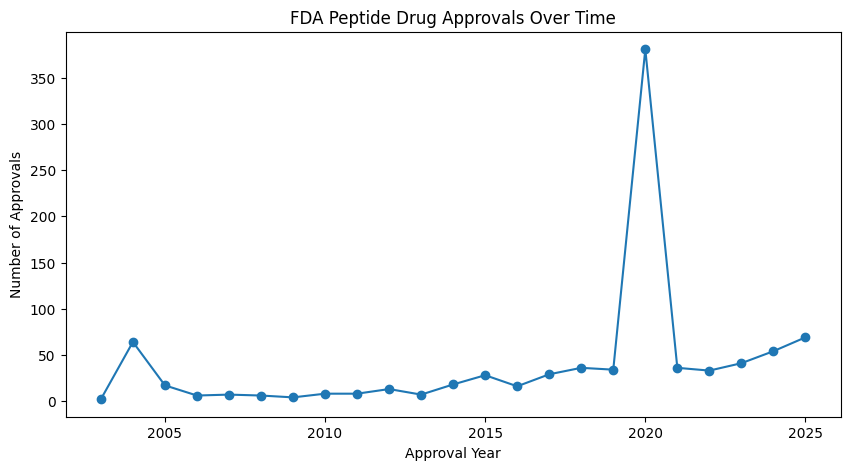

In [41]:
plt.figure(figsize=(10,5))
approvals_per_year.plot(kind='line', marker='o')
plt.title('FDA Peptide Drug Approvals Over Time')
plt.xlabel('Approval Year')
plt.ylabel('Number of Approvals')
plt.show()

FDA approvals for peptide therapeutics show a gradual increase, highlighting growing confidence in peptide-based drugs.This trend shows increasing demand of novel therapeutics technology.

#Marketing Status of Peptide drugs

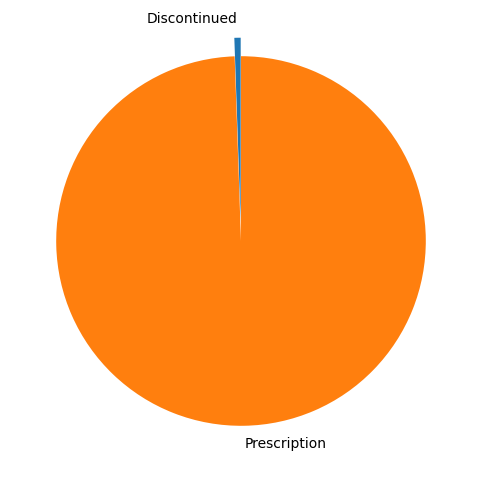

In [42]:
market_status=peptide_drugs.groupby("Status").size().reset_index(name="count")
market_status
plt.figure(figsize=(15,6))
plt.pie(market_status['count'], labels=market_status['Status'],startangle=90,explode=[0.1,0])
plt.show()


/tmp/ipykernel_653/4016661467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ApplicationDocsDate", data=prescribed_peptide, palette="rocket_r")


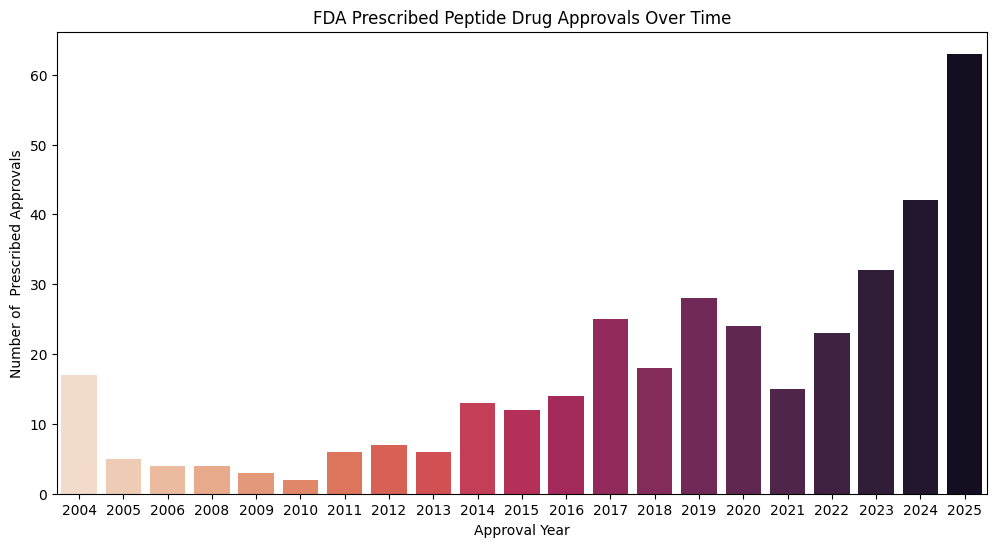

In [43]:
prescribed_peptide=peptide_drugs[peptide_drugs['Status']== "Prescription"]
yearly_peptide=prescribed_peptide.groupby("ApplicationDocsDate").size()
plt.figure(figsize=(12,6))
sns.countplot(x="ApplicationDocsDate", data=prescribed_peptide, palette="rocket_r")
plt.title('FDA Prescribed Peptide Drug Approvals Over Time')
plt.xlabel('Approval Year')
plt.ylabel('Number of  Prescribed Approvals')
plt.show()

In [44]:
discont_peptide=peptide_drugs[peptide_drugs['Status']== "Discontinued"]
discont_yearly_peptide= discont_peptide.groupby("ApplicationDocsDate").size()
discont_yearly_peptide

,0
ApplicationDocsDate,
2004,1
2014,1


Low discontintion rate of Peptide drug and increasing the number of approved drugs per year indicate extended commercial lifecycles, frequent label updates, or manufacturing changes.

# Number of approved drugs of top companies (Market Competitior Analysis)

In [45]:
company_peptide_drugs_count=peptide_drugs.groupby("SponsorName").size().reset_index(name="count").sort_values("count", ascending=False)
top_com=company_peptide_drugs_count.head(15)
top_com

,SponsorName,count
42,GENENTECH INC,43
8,AMGEN INC,17
55,JANSSEN BIOTECH,15
34,ELI LILLY CO,14
22,CELLTRION INC,13
78,SAMSUNG BIOEPIS CO LTD,13
72,PFIZER INC,11
66,NOVARTIS,9
11,ASTRAZENECA AB,9
16,BIOGEN INC,8


/tmp/ipykernel_653/3749523297.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="SponsorName", y="count", data=top_com, palette="hls")


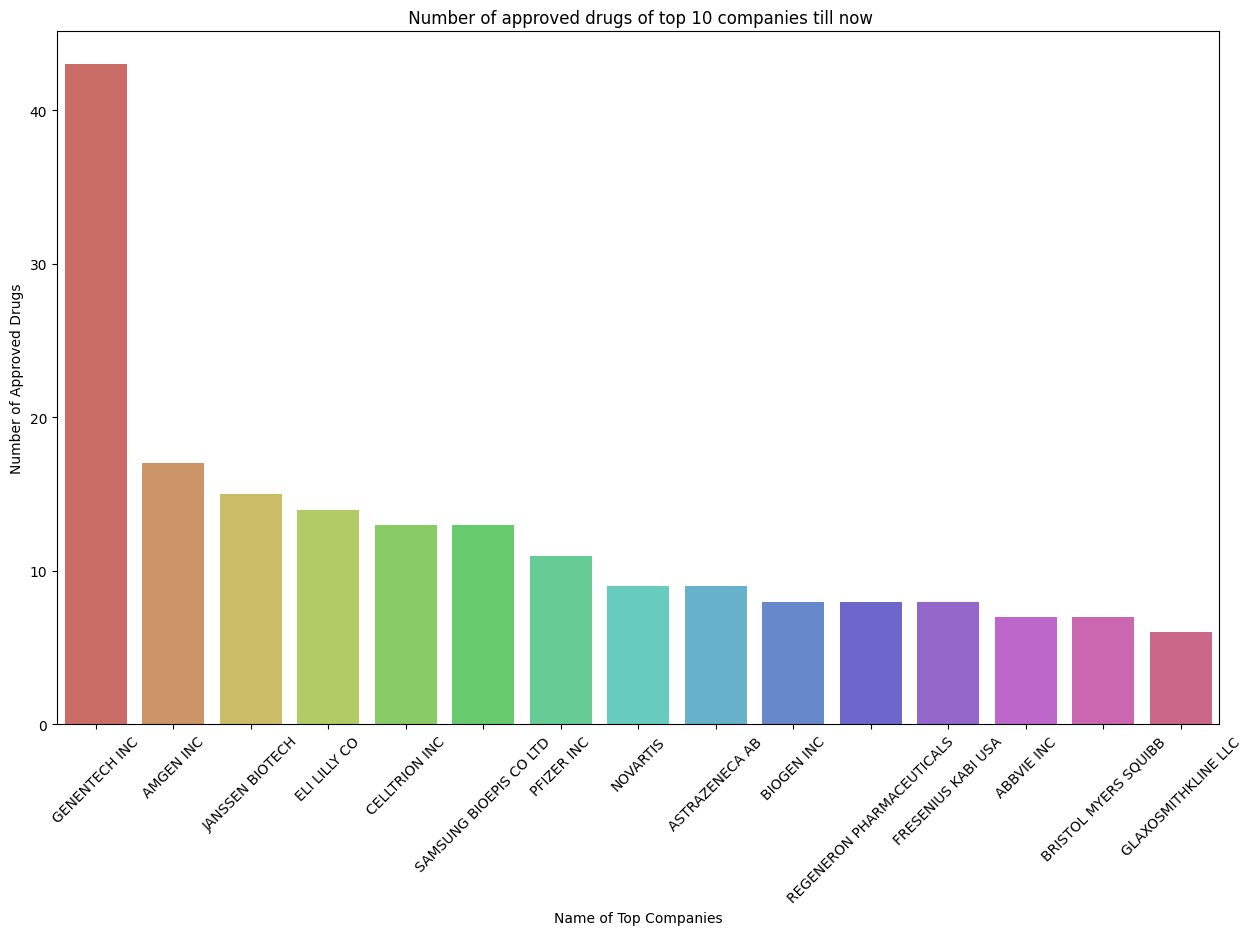

In [46]:
plt.figure(figsize=(15,9))
sns.barplot(x="SponsorName", y="count", data=top_com, palette="hls")
plt.title(" Number of approved drugs of top 10 companies till now")
plt.xlabel('Name of Top Companies')
plt.ylabel('Number of Approved Drugs')
plt.xticks(rotation=45)
plt.show()

## The top Companies in peptide baesd drug approval during the time period of 2015-2025

/tmp/ipykernel_653/4093278211.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="SponsorName", y="count", data=top_com_10years,palette="viridis")


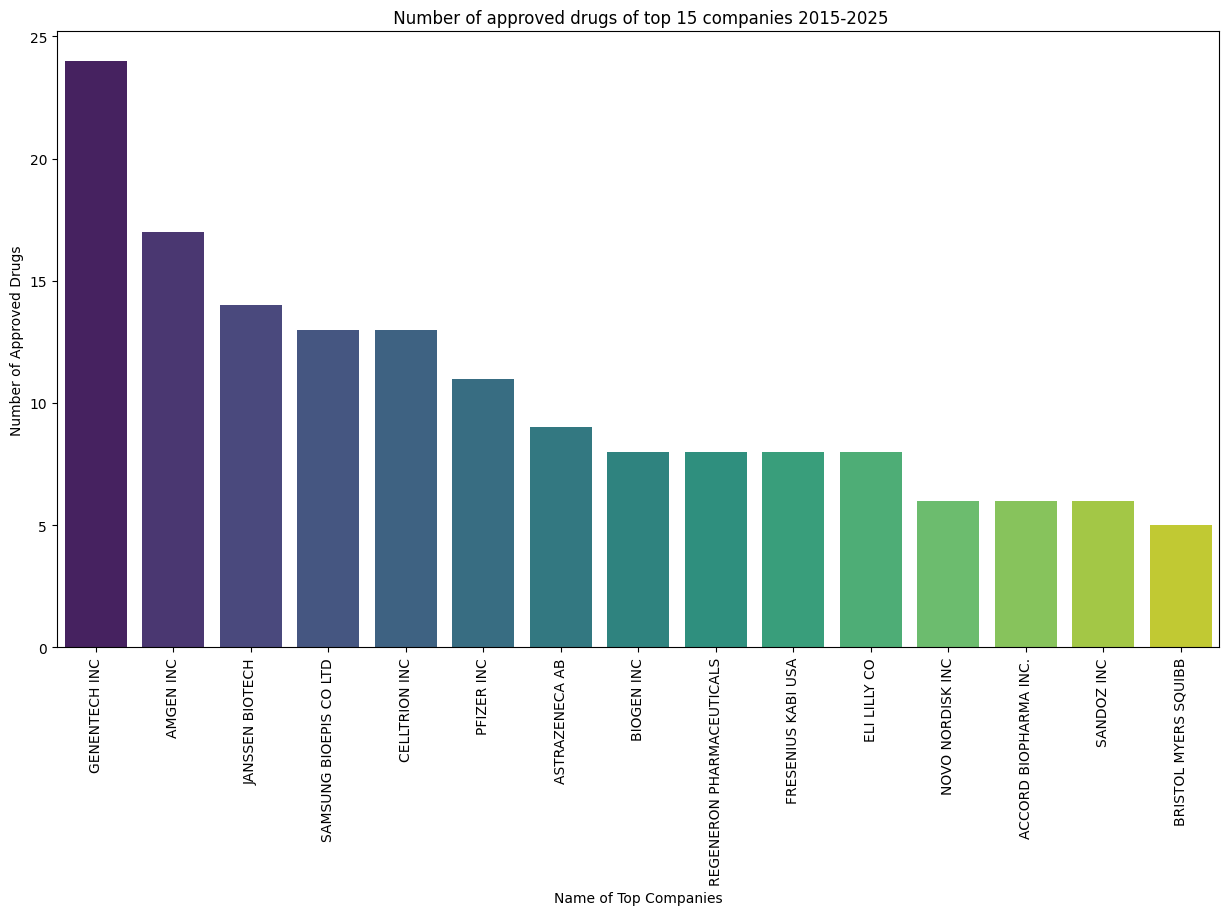

In [47]:
# Top companies that contributed most in last decade
peptide_drugs_10years=peptide_drugs[peptide_drugs['ApplicationDocsDate']>= 2015]
company_peptide_drugs_10yrs_count=peptide_drugs_10years.groupby("SponsorName").size().reset_index(name="count").sort_values("count", ascending=False)
top_com_10years=company_peptide_drugs_10yrs_count.head(15)

plt.figure(figsize=(15,8))
sns.barplot(x="SponsorName", y="count", data=top_com_10years,palette="viridis")
plt.title(" Number of approved drugs of top 15 companies 2015-2025")
plt.xlabel('Name of Top Companies')
plt.ylabel('Number of Approved Drugs')
plt.xticks(rotation=90)
plt.show()

The analysis shows that Genetech Inc follwed by Amgen Inc and Janssen Biotech are the marke leaders of peptide based biologics drugs, contributing the highest number of approvals across the full historical dataset and last decade.

# Formulation and Route of Administration Trends of Peptide based therapeutics

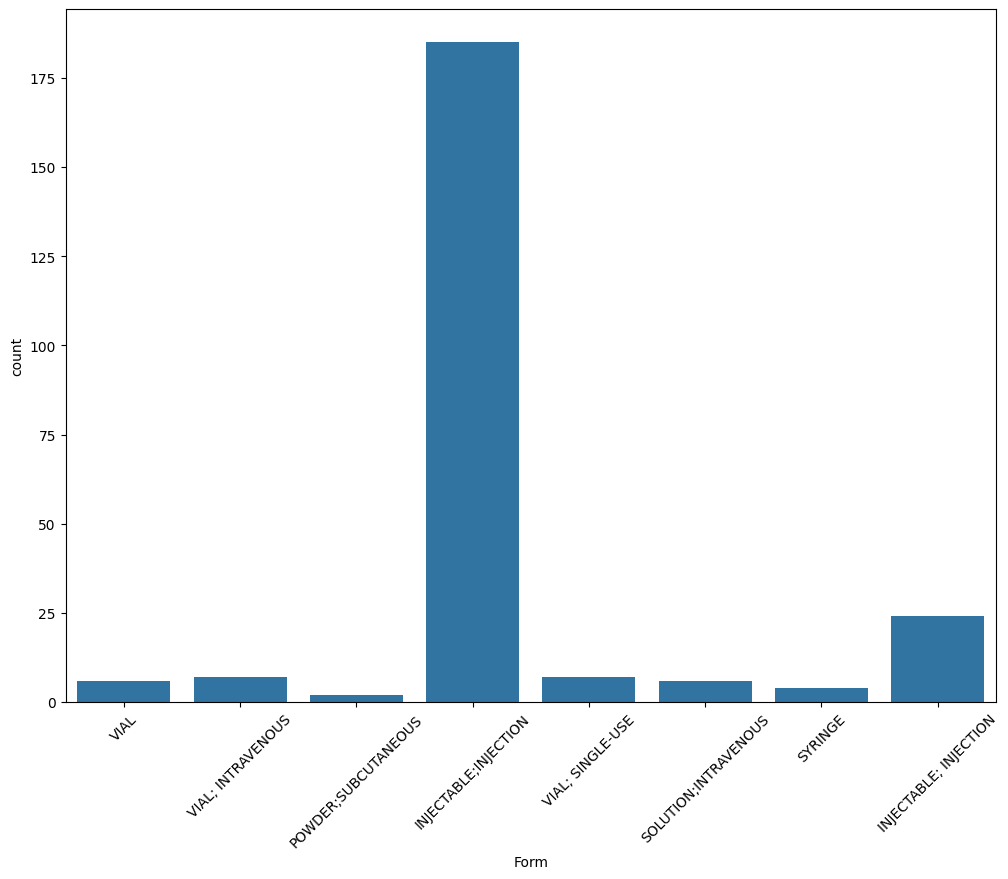

In [48]:
# Plot for Formulation
plt.figure(figsize=(12,9))
sns.countplot(x="Form",data=peptide_drugs, order=peptide_drugs["Form"].head(20).value_counts().index)
plt.xticks(rotation=45)
plt.show()

#Key Performance Indicators of peptide therapeutics

In [49]:
#Total numebr of peptide application
kpi_total_peptide= peptide_drugs['ApplNo'].nunique()
kpi_total_peptide

253

In [50]:
# total number of sponsors
kpi_total_sponsors= peptide_drugs['SponsorName'].nunique()
kpi_total_sponsors

100

In [51]:
#Average kpi for annual approval
kpi_avg_annual_approvals_10years = peptide_drugs_10years['ApplicationDocsDate'].value_counts().mean()
kpi_avg_annual_approvals_10years


np.float64(26.90909090909091)

In [52]:
# KPI discontinued
kpi_discontinued=peptide_drugs['Status'].value_counts(normalize=True)*100
kpi_discontinued=kpi_discontinued.get('Discontinued',1)
kpi_discontinued

np.float64(0.547945205479452)

In [53]:
# Top 5 and 10 company share in the dataset
top5_company_share_10years= (company_peptide_drugs_10yrs_count['count'].head(5).sum())/(company_peptide_drugs_10yrs_count['count'].sum())*100
print(top5_company_share_10years)
top10_company_share_10years= (company_peptide_drugs_10yrs_count['count'].head(10).sum())/(company_peptide_drugs_10yrs_count['count'].sum())*100
print(top10_company_share_10years)


27.364864864864863
42.22972972972973


#Conclusion
1.the steady growth of FDA approved peptide therapeutics, with noticeable acceleration in last decade. This trend indicates increasing demand of novel large molecule therapeutics

2.Sponsor analysis suggests Moderate market concentration, Top market competitors are Genentech Inc, Amgen Inc, Jnassen Biotech,Samsung Bioepis Co Ltd.

3.Formulation analysis confirms that injectable dosage forms overwhelmingly dominate FDA-approved peptide drugs.This highlights the persistent challenges associated with oral peptide delivery, including enzymatic degradation and low bioavailability.

4.The top 10 sponsors from 2015 to 2025 have over half of the peptide drugs, a 0.5% discontinuation rate, and an annual approval rate of 26 products.